In [32]:
from langchain_core.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Annotated, Literal
from typing import List
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
web_search = TavilySearchResults(max_results=2)

C:\Users\ASIF\AppData\Local\Temp\ipykernel_20096\3109834641.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=2)


In [5]:
results=web_search.invoke("US-Iran Talk latest news")

In [6]:
for result in results:
    print(result['content'],"\n------------------------------------------------------------")

... news & analysis, up ... The U.S. team negotiating with Iran is 'out of their league' and uninterested in diplomacy: Expert. 
------------------------------------------------------------
Iran's state media has said Tehran has "no plans for now to participate" in the second round of negotiations with the US about the war, 
------------------------------------------------------------


In [7]:
queries = ["US-Iran Talk latest news", "Role of Pakistan in US-Iran Peace Talk"]
web_results = []
for query in queries:
    results = web_search.invoke(query)
    for result in results:
        web_results.append(result['content'])

In [8]:
context = "\n".join(web_results)
print(type(context))

<class 'str'>


In [10]:
llm_gemini= ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm_gemini.invoke("hi")

AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019da9cc-4183-7382-b3de-8e4e5e5195e1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 220, 'total_tokens': 222, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 210}})

In [11]:
groq_llm = ChatGroq(model="llama-3.3-70b-versatile")
groq_llm.invoke("hi").content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
class Outlines(BaseModel):
    Sections: List[str] = Field(description="What should be the main sections for this topic to research")

In [74]:
class Evaluation(BaseModel):
    improvement_needed: Literal["yes","no"] =Field(description="check whether improvement in given paper is needed or not")
    feedback: str = Field(description="feedback about which sections should improve and need what improvements")

In [28]:
class Queries(BaseModel):
    queries: List[str] =Field(description="Give multiple queries for specific given topic to do web search for getting context to write a research paper for given topic")

In [29]:
class GraphState(TypedDict):
    topic: str
    queries: Queries
    context: str
    Sections: Outlines
    paper: str
    evaluation: Evaluation

In [57]:
llm_queries = llm_gemini.with_structured_output(Queries)
def query_generator(state: GraphState):
    topic = state['topic']
    Query_SYS_Prompt = """You are an expert in generating multiple queries for a given topic.
                    Against these queries there will be web search to get context for this topic. 
                    So, give list of 5-8 Queries for getting relevant info for given topic, to write a comprehensive research paper on this topic."""
                    
    response = llm_queries.invoke(
        [
            SystemMessage(content=Query_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}")
        ]
    )
    
    return {"queries": response}

In [58]:
def webSearch(state: GraphState):
    queries_list = state['queries'].queries
    
    web_results = []
    
    for query in queries_list:
        results = web_search.invoke(query)
        for result in results:
            web_results.append(result['content'])
            
    context = "\n".join(web_results)
    
    return {"context": context}

In [59]:
llm_with_planning = groq_llm.with_structured_output(Outlines)

def planner(state: GraphState):
    topic = state['topic']
    context = state['context']
    
    planner_SYS_Prompt = """You are an expert in planning that what should be the sections for a research paper based on given topic and web-searched context. 
    You will be given topic upon which there will be written comprehensive research paper, and also web-searched context will be given so that based on these you give main-haeadings that are sections and also reason and idea what should be in these sections.
    SO always, give list of main sections based on that the writer will compose a comprehensive research paper for given topic, always keep in mind topic and given web-searched context for giving sections for research paper"""
    
    response = llm_with_planning.invoke(
        [
            SystemMessage(content=planner_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nContext: {context}")
        ]
    )
    
    return {"Sections": response}

In [73]:
def writer(state: GraphState):
    topic = state['topic']
    sections = state['Sections'].Sections
    context = state['context']
    
    writer_SYS_Prompt = """You are an expert in writing a comprehensive research paper for a given topic of interest. 
    You will be given topic, web-searched context and the main sections based on that you have to write a comprehensive research paper for given topic. 
    The research paper should be accurate, complete and cover all given sections with well detail, so that paper looks great to read and clears everything about this topic. """
    
    paper = llm_gemini.invoke(
        [
            SystemMessage(content=writer_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\n Context: {context}\n\nMain Sections for paper: {sections}")
        ]
    )
    
    return {"paper":paper}

In [77]:
paper.content

'## Artificial Intelligence: A Comprehensive Overview\n\n### Abstract\nArtificial Intelligence (AI) represents a paradigm shift in computing, enabling machines to perform tasks traditionally requiring human intelligence. This paper provides a comprehensive exploration of AI, from its foundational definitions and historical trajectory to its diverse applications across various industries, the ethical considerations it engenders, and its projected future impact on society. We delve into key AI concepts such as machine learning, deep learning, and neural networks, differentiating between narrow AI, Artificial General Intelligence (AGI), and Artificial Superintelligence (ASI). Furthermore, we examine AI\'s transformative role in sectors like healthcare, manufacturing, and retail, while critically addressing pressing ethical challenges such as bias, accountability, and the impact on employment. The paper concludes by emphasizing the imperative for responsible development and governance to h

In [78]:
evaluation_llm = groq_llm.with_structured_output(Evaluation)
topic = "AI"
context = context
paper = paper.content
    
Evaluator_SYS_Prompt = """You are an expert for evaluation of research paper.
    You will be given the topic of interest for which user wants a research paper, and also web-searched context for specific topic,
    and also the main paper is given.
    You have to evaluate whether given paper whether it is good or need improvement, 
    always evaluate paper based on completeness, fairness, accurateness and no-harmness and intended one. 
    If you realize improvement needed then set improvement_needed='yes' otherwise 'no', and also give feedback if improvement needed.
    in feedback states which section should be improved and what improvement is needed."""
    
evaluation = evaluation_llm.invoke(
        [
            SystemMessage(content=Evaluator_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nContext: \n{context}\n\nResearch Paper: \n{paper}")
        ]
    )

In [79]:
evaluation

Evaluation(improvement_needed='yes', feedback="The research paper on Artificial Intelligence (AI) is comprehensive, covering various aspects such as definitions, history, types, applications, and ethical implications. However, there are a few sections that could be improved for better clarity and depth. Firstly, the section on 'Types of AI' could be expanded to include more details on Narrow AI, AGI, and ASI, and their current development status. Secondly, the 'Applications of AI' section, while extensive, could benefit from more specific examples and case studies to illustrate the impact of AI in different industries. Lastly, the 'Ethical Implications' section, while touching on important points, could delve deeper into the challenges of bias, accountability, and transparency, and propose more concrete solutions for addressing these issues. Additionally, the paper could benefit from a more detailed analysis of the future of AI, including potential advancements, challenges, and societa

In [80]:
evaluation_llm = groq_llm.with_structured_output(Evaluation)

def evaluator(state: GraphState):
    topic = state['topic']
    context = state['context']
    paper = state['paper']
    
    Evaluator_SYS_Prompt = """You are an expert for evaluation of research paper.
    You will be given the topic of interest for which user wants a research paper, and also web-searched context for specific topic,
    and also the main paper is given.
    You have to evaluate whether given paper whether it is good or need improvement, 
    always evaluate paper based on completeness, fairness, accurateness and no-harmness and intended one. 
    If you realize improvement needed then set improvement_needed='yes' otherwise 'no', and also give feedback if improvement needed.
    in feedback states which section should be improved and what improvement is needed."""
    
    evaluation = evaluation_llm.invoke(
        [
            SystemMessage(content=Evaluator_SYS_Prompt),
            HumanMessage(content=f"Topic: {topic}\n\nContext: \n{context}\n\nResearch Paper: \n{paper}")
        ]
    )
    
    return {"evaluation": evaluation}

In [81]:
def router(state: GraphState):
    improvement_needed = state['evaluation'].improvement_needed
    
    if improvement_needed == 'yes':
        return "improvement_needed"
    else:
        return "not_needed"

In [ ]:
def rewriter(state: GraphState):
    topic = state['topic']
    context = state['context']
    paper = state['paper']
    feedback = state['evaluation'].feedback
    
    

In [22]:
def downable_html(state: GraphState):
    pass

In [15]:
builder = StateGraph(GraphState)

In [24]:
builder.add_node("query_generator", query_generator)
builder.add_node("webSearch", webSearch)
builder.add_node("planner", planner)
builder.add_node("writer", writer)
builder.add_node("evaluator", evaluator)
builder.add_node("rewriter", rewriter)
builder.add_node("downable_html", downable_html)

builder.add_edge(START, "query_generator")
builder.add_edge("query_generator", "webSearch")
builder.add_edge("webSearch", "planner")
builder.add_edge("planner", "writer")
builder.add_edge("writer", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    router,
    {
        "no needed": "downable_html",
        "needed": "rewriter"
    }
)
builder.add_edge("rewriter", "evaluator")
builder.add_edge("downable_html", END)

graph = builder.compile()

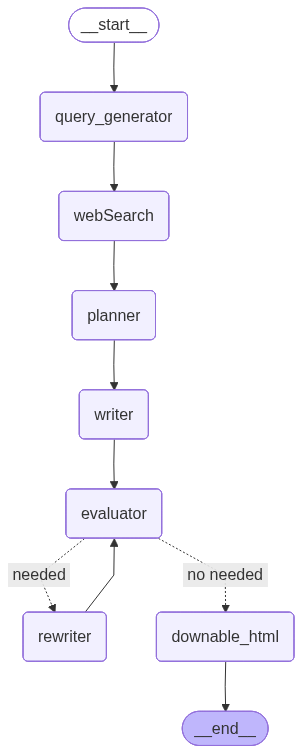

In [27]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))